In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import json

0.626136824736047
0.7976441133618146


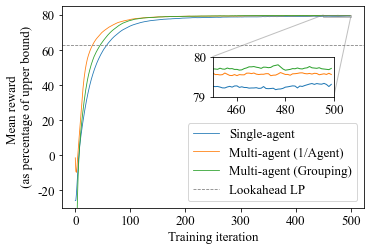

In [10]:
#create a graph comparing the performance of multi-agent architectures
pids = ["cheese_022", "cheese_022_1perAgent", "cheese_022_group"]
labels = ["Single-agent", "Multi-agent (1/Agent)", "Multi-agent (Grouping)"]
#load training progress from CSV file

#load data
data = {}
for pid in pids:
    data[pid] = pd.read_csv(f"{os.getcwd()}/cheese/{pid}/training_progress.csv")
    data[pid]["average_reward_estimate"] = (data[pid]["average_reward_estimate"]+1)/2

#change plot font to Times New Roman
#plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 13

#get LP eval for reference
with open(f"{os.getcwd()}/cheese/cheese_022/training_results/full_blending_full_nn_none_lp_100w/regression_data_crn_heuristic.json") as f:
    LP_results = json.load(f)
#get DRL eval results
with open(f"{os.getcwd()}/cheese/cheese_022/training_results/full_blending_full_nn_none_lp_100w/regression_data_crn.json") as f:
    eval_results = json.load(f)


avg_LP_reward = (np.mean(LP_results["rewards"])+1)/2
print(avg_LP_reward)
avg_eval_reward = (np.mean(eval_results["rewards"])+1)/2
print(avg_eval_reward) 


#plot data
plt.rcParams["font.family"] = "Times New Roman"
fig, ax = plt.subplots(figsize=(6, 4))
for pid in pids:
    ax.plot(data[pid]["Step"], data[pid]["average_reward_estimate"], label=labels[pids.index(pid)], linewidth=0.8)
ax.axhline(y=avg_LP_reward, color='grey', linestyle='--', label="Lookahead LP", linewidth=0.8)
ax.set(xlabel="Training iteration", ylabel="Mean reward \n (as percentage of upper bound)")
ax.set_ylim(-0.3, 0.85)
ax.legend()

#add a window to zoom in on the last 30 iterations
axins = ax.inset_axes([0.5, 0.55, 0.4, 0.2])
for pid in pids:
    axins.plot(data[pid]["Step"], data[pid]["average_reward_estimate"], label=labels[pids.index(pid)], linewidth=1)
axins.set_xlim(450, 500)
axins.set_yticks([0.79, 0.80], [79, 80])
axins.set_ylim(0.79, 0.80)
ax.set_yticks([-0.2,0.0,0.2,0.4,0.6,0.8], [-20, 0, 20, 40, 60, 80])
ax.indicate_inset_zoom(axins)

#add more space left and bottom
plt.subplots_adjust(left=0.15, right=0.85, top=0.85, bottom=0.15)

plt.savefig(f"{os.getcwd()}/figures/cheese_022_method_comparison.pdf")
plt.show()



In [8]:
#time per iteration analysis
pids = ["cheese_010", "cheese_010_1perAgent", "cheese_010_group"]

#read data from json files
data = {}
for pid in pids:
    data[pid] = json.load(open(f"{os.getcwd()}/cheese/{pid}/training_results/time_per_iteration.json")) 

#print average time per iteration as a factor of the single-agent time
for pid in pids:
    print(f"{pid}: {np.mean(data[pid])/np.mean(data['cheese_010'])}")

#get eval results
with open(f"{os.getcwd()}/cheese/cheese_010/training_results/full_blending_full_nn_none_lp_100w/regression_data_crn.json") as f:
    eval_results = json.load(f)
#get no blending results
with open(f"{os.getcwd()}/cheese/cheese_010/training_results/no_blending_full_nn_none_lp_75w/regression_data_crn_nob.json") as f:
    nob_results = json.load(f)

avg_eval_reward = (np.mean(eval_results["rewards"])+1)/2
avg_nob_reward = (np.mean(nob_results["rewards"])+1)/2

print(avg_eval_reward)
print(avg_nob_reward)

cheese_010: 1.0
cheese_010_1perAgent: 5.481155284774227
cheese_010_group: 2.4818164872871047
0.7979055136359079
0.8214646696045982
